---
tags: [integration, optimization, variational]
---

# QURI Parts Support

This page shows how to use Qamomile's [QURI Parts](https://quri-parts.qunasys.com/) quantum SDK integration through a concrete optimization problem.
In this tutorial, we use QAOA optimization for a small MaxCut instance as an example. We transpile a Qamomile qkernel to a QURI Parts circuit, then run sampling and expectation-value evaluation.
`QuriPartsExecutor` uses [Qulacs](https://docs.qulacs.org/), a fast C++ state-vector simulator, by default, so the examples below run on a local CPU without any extra configuration.

In [1]:
# Install the latest Qamomile with the QURI Parts extras through pip.
# !pip install "qamomile[quri_parts]"

## The MaxCut problem

We use the same small 5-node graph from the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb) so the focus stays on the QURI Parts integration.
Maximizing $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ is equivalent, up to a constant, to *minimizing* the antiferromagnetic Ising Hamiltonian $H_C = \sum_{(i,j) \in E} s_i s_j$.
For unweighted MaxCut, every $J_{ij} = 1$ and every $h_i = 0$, so we pass these coefficients directly to `BinaryModel.from_ising`.
We use the model object for the `quad` / `linear` dictionaries passed to the QAOA qkernel and for decoding measurements back into spin values $(+1 / -1)$.

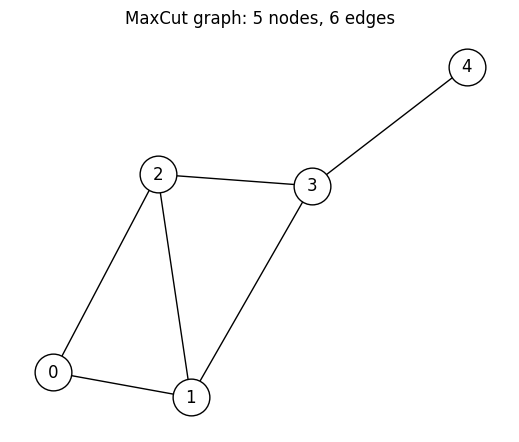

In [3]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qamomile.optimization.binary_model import BinaryModel

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# The problem structure is fully determined by the graph: one quad term per edge
# and no linear terms for unweighted MaxCut. Assert so a regression in
# `BinaryModel.from_ising` is caught when this notebook runs in CI.
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## Building the QAOA ansatz with `@qkernel`

We write reusable qkernels for the QAOA state, sampling ansatz, and expectation-value evaluation.
The recipe is the same as in the [QAOA for MaxCut tutorial](../algorithm/qaoa_maxcut.ipynb). After preparing a uniform superposition in the computational basis, we alternately apply cost and mixer layers $p$ times.
The sampling qkernel measures the final state in the computational basis, while the expectation-value qkernel evaluates the same state against a Hamiltonian.

:::{tip}
Qamomile's rotation gates follow the $e^{-i\theta/2}$ convention.
Because of that, the $1/2$ factor is handled slightly differently in the cost and mixer layers.
In the mixer layer, we pass $2\beta$ to `rx`, so the $1/2$ cancels and we get the textbook $e^{-i\beta X}$.
In the cost layer, we pass $J_{ij} \cdot \gamma$ to `rzz`, so the $1/2$ remains.
We absorb this coefficient difference into the variational parameter $\gamma$: the $\gamma$ used here is twice the textbook QAOA $\gamma$.
:::

In [4]:
import qamomile.circuit as qmc


@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    # Prepare a uniform superposition over all graph nodes.
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    # Encode quadratic and linear Ising terms as phase rotations.
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    # Mix amplitudes with X rotations on every qubit.
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_state(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Qubit]:
    # Prepare the final QAOA state without measuring it.
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    # Measure the final QAOA state for sampling.
    q = qaoa_state(p, quad, linear, n, gammas, betas)
    return qmc.measure(q)


@qmc.qkernel
def qaoa_energy(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    # Evaluate the same QAOA state against a Hamiltonian observable.
    q = qaoa_state(p, quad, linear, n, gammas, betas)
    return qmc.expval(q, H)

`qaoa_ansatz.draw(...)` renders the Qamomile circuit diagram.
We pass concrete values for the arguments that determine the problem structure (`p`, `quad`, `linear`, `n`) so the layered shape is visible.
Meanwhile, `gammas` / `betas` are left as parameters whose values are supplied later.

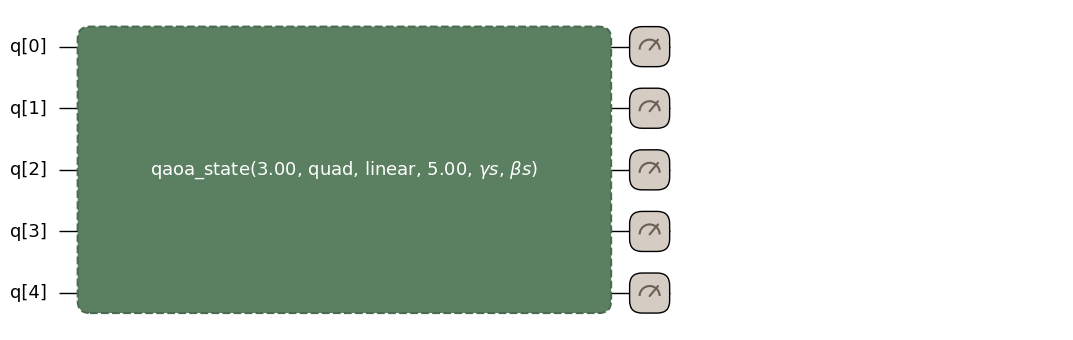

In [5]:
# Draw the Qamomile-level QAOA ansatz for the fixed problem shape.
p = 3  # number of QAOA layers
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## Transpile to QURI Parts

`QuriPartsTranspiler` is used with `transpile()` the same way as any other quantum SDK.
We bind the arguments that determine the problem structure and keep `gammas` / `betas` as runtime parameters.

In [6]:
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler

transpiler = QuriPartsTranspiler()
# Passing a `seed` makes the Qulacs sampler reproducible: two `sample(...)`
# calls with the same seed and circuit return identical shot counts. Omit it
# (or pass `seed=None`) for non-deterministic sampling.
executor = QuriPartsExecutor(seed=42)

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()` returns the generated QURI Parts circuit.
The returned circuit is a QURI Parts `LinearMappedParametricQuantumCircuit`, and the $2p$ QAOA angles (`gammas[0..p-1]`, `betas[0..p-1]`) remain available as named runtime parameters.
We can confirm that with `type(...)` and the parameter count, then inspect the circuit directly with QURI Parts' built-in `draw_circuit`.

In [7]:
# Inspect the generated QURI Parts circuit and verify its qubit and parameter counts.
quri_circuit = executable.get_first_circuit()
# Here, transpile() generates exactly one quantum segment.
assert quri_circuit is not None
# `qubit_count` and `parameter_count` are fully determined by the problem setting:
# one qubit per graph node, and one runtime parameter per (gamma | beta) per layer.
assert quri_circuit.qubit_count == num_nodes
assert quri_circuit.parameter_count == 2 * p
print(type(quri_circuit).__name__)
print("qubit_count    :", quri_circuit.qubit_count)
print("parameter_count:", quri_circuit.parameter_count)

draw_circuit(quri_circuit, line_length=200)

LinearMappedParametricQuantumCircuit
qubit_count    : 5
parameter_count: 6
   ___     ___     ___     ___                     ___     ___     ___                     ___     ___     ___                                  
  | H |   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                                 
--|0  |---|5  |---|6  |---|11 |-------------------|16 |---|17 |---|22 |-------------------|27 |---|28 |---|33 |---------------------------------
  |___|   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                                 
   ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___                  
  | H |   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|                 
--|1  |---|   |----| |----|7  |---|8  |---|12 |---|   |

Each runtime parameter remains unbound until execution time.
That means binding `gammas` / `betas` is treated as a parameter-value update on the QURI Parts side rather than a circuit rebuild.
The problem structure, such as the Ising coefficients, qubit count, and number of layers, is fixed when the circuit is transpiled, leaving only the variational angles as runtime inputs.

## Sampling QAOA with `QuriPartsExecutor`

`executable.sample(executor, bindings=..., shots=...)` returns a `SampleJob`.
Calling `.result()` gives a `SampleResult`, which `BinaryModel.decode_from_sampleresult` decodes into a `BinarySampleSet` of spin variables $(+1 / -1)$.
This lets us count cut edges without any additional conversion.
`QuriPartsExecutor()` runs against the Qulacs state-vector simulator by default.

In [8]:
# Choose reproducible initial angles and keep docs-test runs short.
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

# Sample the parameterized executable and decode bitstrings to Ising energies.
sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6430


## Optimizing the QAOA parameters

A QAOA optimization loop reuses the same `executable` across many `(gammas, betas)` vectors.
Call `transpiler.transpile()` once, then call `executable.sample()` many times.
In this example, we define the sampling and decoding work as `cost_fn()` and optimize it with SciPy's `minimize` function.
The classical optimizer updates `(gammas, betas)` while lowering the mean sampled Ising energy.
Each iteration reuses the same `executable` and `QuriPartsExecutor`.

In [9]:
from scipy.optimize import minimize

cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


# Optimize the sampled mean energy with COBYLA.
res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.9290
Optimal gammas       : [0.9127, -0.3821, 1.418]
Optimal betas        : [0.3279, -0.7588, 2.9612]


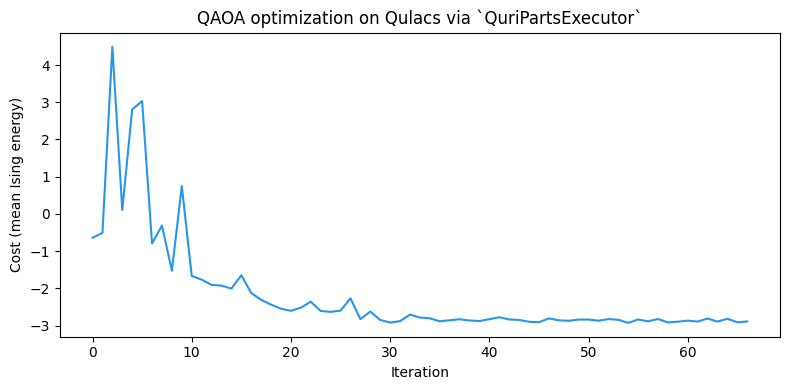

In [10]:
# Plot the objective values collected during optimization.
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Qulacs via `QuriPartsExecutor`")
plt.tight_layout()
plt.show()

Because the `QuriPartsExecutor` above was constructed with `seed=42`, the Qulacs sampler is reproducible, so re-running this page yields the same optimization trajectory and final energy; drop the `seed` argument to recover the original non-deterministic behavior.
The optimizer should converge close to the ground-state energy of $H_C$ on this 5-node graph.
The optimized parameters from this run (`opt_gammas`, `opt_betas`) are reused throughout the rest of this page.

## Expectation values with `run()`

In Qamomile, you write expectation values in a qkernel with `qmc.expval(...)`.
When this is transpiled to QURI Parts, it becomes an executable object that can be called with `ExecutableProgram.run(executor, bindings=...)`.
`run()` uses Qamomile's recorded parameter information to bind runtime parameters before calling the QURI Parts estimator.

First build a Qamomile `Hamiltonian` for $H_C = \sum_{(i,j) \in E} Z_i Z_j$.
Then transpile the expectation-value qkernel and evaluate it at the optimized QAOA parameters.

In [11]:
# Build the Qamomile Hamiltonian that matches the MaxCut Ising cost.
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

# Transpile the expectation-value qkernel and evaluate it with `run()`.
expval_executable = transpiler.transpile(
    qaoa_energy,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "H": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_via_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"Executable.run() expectation: {energy_via_run:+.10f}")
print(f"sample mean energy          : {res.fun:+.4f}")
assert np.isfinite(energy_via_run)

Executable.run() expectation: -2.8538574303
sample mean energy          : -2.8810


`ExecutableProgram.run(...)` is the recommended route when you work through the Qamomile API.
Direct `executor.estimate(...)` and `executor.estimate_expectation(...)` calls are still available when you intentionally manage QURI Parts circuits yourself.
On the `run()` path, Qamomile binds the named runtime parameters before the estimator call, so you do not need to manage QURI Parts' flat parameter order yourself.

The next section opens that lower-level path and shows how QURI Parts handles unbound and already-bound circuits differently.

## Advanced QURI Parts features

QURI Parts exposes both parametric and non-parametric estimator paths.
Qamomile normally hides that distinction behind `ExecutableProgram.run(...)` or `executor.estimate(...)`, but direct `estimate_expectation(...)` calls are useful when you need full control over the QURI Parts circuit.

### Expectation values: unbound circuits and bound circuits

`QuriPartsExecutor.estimate_expectation(circuit, hamiltonian, param_values)` computes expectation values with QURI Parts.
It chooses between two QURI Parts estimators depending on the **state of the circuit it receives**:

- **Unbound parametric circuit**: the circuit produced by `transpile()` still keeps its parameters as free variables.
  QURI Parts' `apply_circuit` wraps it as a `ParametricCircuitQuantumState`, and the executor calls QURI Parts' **parametric estimator**.
  In this case, `param_values` is used to bind the parameters at evaluation time.
- **Bound circuit, or a circuit with no parameters from the start**: once parameters are fixed to concrete values, for example with `circuit.bind_parameters([...])`, the same `apply_circuit` call returns a `GeneralCircuitQuantumState`.
  In this case, the executor calls QURI Parts' **non-parametric estimator**, and `param_values` is ignored.

This distinction helps when estimating computation cost.
The parametric estimator is a good fit for optimization loops that evaluate the same circuit many times with different parameters, because it avoids a circuit copy at each iteration.
If the parameters are already fixed to concrete values, the non-parametric estimator can be more efficient because it avoids parametric-circuit bookkeeping.

QURI Parts treats `measure` as a no-op at the circuit level.
Therefore, the parametric circuit generated by `transpiler.transpile(qaoa_ansatz, ...)` can be used directly as the QAOA state preparation circuit for $|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$.
We can pass it to `estimate_expectation` together with the cost Hamiltonian to compute $\langle H_C \rangle$ without sampling noise.
In a QAOA optimizer, you can keep the same circuit and replace `executable.sample()` plus decoding with `executor.estimate(circuit, hamiltonian, params=...)`.

To try both paths directly, convert the Hamiltonian from the previous section to a QURI Parts operator and call `estimate_expectation` for each circuit variant.

In [10]:
import qamomile.observable as qm_o
from qamomile.quri_parts.observable import hamiltonian_to_quri_operator

cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

quri_H = hamiltonian_to_quri_operator(cost_hamiltonian)

# The unbound parametric circuit straight out of transpiler.transpile().
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
print(f"unbound type           : {type(unbound_circuit).__name__}")
print(f"unbound parameter_count: {unbound_circuit.parameter_count}")

# QURI Parts requires the runtime parameters as a flat list in the order
# they were registered on the circuit, which is the first-use order during
# circuit generation. For QAOA that means gammas[0], betas[0], gammas[1], betas[1],
# ..., interleaved per layer, NOT all gammas followed by all betas.
# Read the order from the executable and build the flat list by lookup so
# we never have to guess the convention.
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# The runtime parameter set is the 2p QAOA angles.
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"circuit parameter order: {executable.parameter_names}")

# Manually bind the same numeric values using QURI Parts' native binding operation.
bound_circuit = unbound_circuit.bind_parameters(flat_params)
print(f"bound   type           : {type(bound_circuit).__name__}")

# Path 1: unbound -> parametric estimator. param_values is consumed.
energy_unbound = executor.estimate_expectation(
    unbound_circuit, quri_H, flat_params
)

# Path 2: bound -> non-parametric estimator. param_values is ignored.
energy_bound = executor.estimate_expectation(bound_circuit, quri_H, [])

print(f"parametric  estimator: {energy_unbound:+.10f}")
print(f"non-param.  estimator: {energy_bound:+.10f}")
assert np.isclose(energy_unbound, energy_bound, atol=1e-10)
assert np.isclose(energy_via_run, energy_unbound, atol=1e-10)

unbound type           : LinearMappedParametricQuantumCircuit
unbound parameter_count: 6
circuit parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
bound   type           : ImmutableBoundParametricQuantumCircuit
parametric  estimator: -2.8558738580
non-param.  estimator: -2.8558738580


Both paths agree to numerical precision.
They evaluate the same QAOA state against the same Ising cost Hamiltonian.
The resulting noise-free expectation value at the optimized parameters should also match the sample-mean energy printed earlier within shot noise.
This path selection is hidden inside Qamomile's `executor.estimate()` interface, so you normally do not need to think about it.
Call `estimate_expectation` directly only when you need to manage the QURI Parts circuit yourself.

`executor.estimate(circuit, hamiltonian, params=...)` is the easier method when you want to pass an existing QURI Parts circuit but keep Qamomile's Hamiltonian object.
It accepts a `qamomile.observable.Hamiltonian` directly, converts it automatically, and then calls `estimate_expectation`.

In [11]:
# Use the estimator that accepts a Qamomile Hamiltonian directly.
energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate     : {energy_via_estimate:+.10f}")
assert np.isclose(energy_via_estimate, energy_unbound, atol=1e-10)

executor.estimate     : -2.8558738580


## Using other QURI Parts samplers and estimators

`QuriPartsExecutor()` lazily creates the default Qulacs state-vector sampler and parametric estimator on first use.
To swap QURI Parts' sampler or estimator, pass it through `QuriPartsTranspiler.executor(sampler=..., estimator=...)`, or instantiate `QuriPartsExecutor(sampler=..., estimator=...)` directly.
The custom executor can be used anywhere `executor` appeared above.
Swapping the sampler does not require re-transpiling the kernel.
The executable carries the circuit, while the executor carries the sampler or estimator used for execution.

As a concrete example, we build a noisy sampler with QURI Parts' Qulacs `NoiseSimulator`.
Then we compare the noiseless and noisy sample-mean energies at the **same** optimized parameters.
With depolarizing noise applied to every gate, the noisy mean energy should drift away from the noise-free value.
This confirms that the swapped sampler is actually being used.

In [12]:
# Build a Qulacs noise-simulator sampler and inject it into the executor.
noise_model = NoiseModel([DepolarizingNoise(error_prob=0.02)])
noisy_sampler = create_qulacs_noisesimulator_sampler(noise_model)
noisy_executor = transpiler.executor(sampler=noisy_sampler)

# Run the same executable on the noiseless and noisy samplers.
clean_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noisy_result = executable.sample(
    noisy_executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()

clean_energy = spin_model.decode_from_sampleresult(clean_result).energy_mean()
noisy_energy = spin_model.decode_from_sampleresult(noisy_result).energy_mean()
print(f"noiseless sampler mean energy: {clean_energy:+.4f}")
print(f"noisy     sampler mean energy: {noisy_energy:+.4f}")

noiseless sampler mean energy: -2.8120
noisy     sampler mean energy: -1.6150


Because both sampler runs return shot counts, we can compare their sampled energy distributions directly.
The vertical line in each subplot marks the sample mean energy.

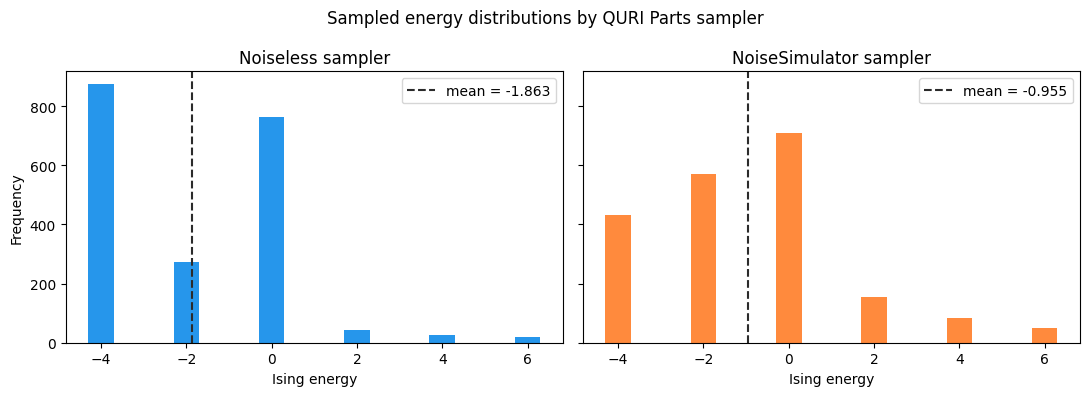

In [14]:


def energy_distribution(decoded_samples):
    counts: Counter[float] = Counter()
    for energy, occ in zip(decoded_samples.energy, decoded_samples.num_occurrences):
        counts[energy] += occ
    energies = sorted(counts.keys())
    return energies, [counts[energy] for energy in energies]


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, decoded_samples, mean_energy, title, color in [
    (axes[0], clean_decoded, clean_energy, "Noiseless sampler", "#2696EB"),
    (
        axes[1],
        noisy_decoded,
        noisy_energy,
        "NoiseSimulator sampler",
        "#FF8A3D",
    ),
]:
    energies, counts = energy_distribution(decoded_samples)
    ax.bar(energies, counts, width=0.6, color=color)
    ax.axvline(
        mean_energy,
        color="#2B2B2B",
        linestyle="--",
        linewidth=1.5,
        label=f"mean = {mean_energy:+.3f}",
    )
    ax.set_xticks(energies)
    ax.set_title(title)
    ax.set_xlabel("Ising energy")
    ax.legend()

axes[0].set_ylabel("Frequency")
fig.suptitle("Sampled energy distributions by QURI Parts sampler")
fig.tight_layout()
plt.show()

Depolarizing noise pushes the QAOA state toward the maximally mixed state.
In that limit, every spin configuration is equally likely, and the mean of $H_C$ converges to $0$.
The noisy mean energy is therefore closer to 0, meaning higher, than the noiseless one.
Increasing `error_prob` or adding more noise channels pushes the noisy energy further toward $0$.
Setting `error_prob=0.0` recovers the noiseless value within shot noise.
The same pattern applies when swapping in any other QURI Parts sampler, such as a remote device, a density-matrix simulator, or a stochastic state-vector sampler.
In all cases, the kernel does not need to be transpiled again.

## Summary

- `QuriPartsTranspiler().transpile(kernel, bindings=..., parameters=[...])` converts the qkernel to a QURI Parts `LinearMappedParametricQuantumCircuit`, which can be inspected with QURI Parts' `draw_circuit`.
- `QuriPartsExecutor` supports `executable.sample()` for QAOA-style sampling, `executable.run()` for qkernels that return `qmc.expval(...)`, and direct `executor.estimate(...)` calls for circuit-level expectation values against the Qulacs state-vector simulator by default.
- `estimate_expectation` switches between QURI Parts' parametric and non-parametric estimators depending on whether the input circuit still has free parameters. Usually, `executor.estimate()` lets you use this behavior without thinking about the switch.
- Custom samplers and estimators, including QURI Parts' `NoiseSimulator`-backed sampler, can be passed through `transpiler.executor(...)` without re-transpiling the kernel.

### See also

- [CUDA-Q Support](cudaq_support.ipynb) covers the same MaxCut QAOA workflow on the CUDA-Q backend.